In [ ]:
pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 2.2 MB/s eta 0:00:00


[*********************100%***********************]  1 of 1 completed

1. Fetching 10 Years of Nifty 50 Data...
2. Engineering Features (Returns & Volatility)...
3. Training the Hidden Markov Model (Unsupervised)...



📊 HMM REGIME INTELLIGENCE REPORT
Regime 0:
  -> Average Daily Return: 0.053%
  -> Daily Volatility:     0.757%
  -> Days Spent in Regime: 2209 days
------------------------------
Regime 1:
  -> Average Daily Return: -0.015%
  -> Daily Volatility:     2.170%
  -> Days Spent in Regime: 296 days
------------------------------

🔄 THE TRANSITION MATRIX (Probability of switching regimes tomorrow):
[[0.993 0.007]
 [0.048 0.952]]

Generating Market Regime Chart...


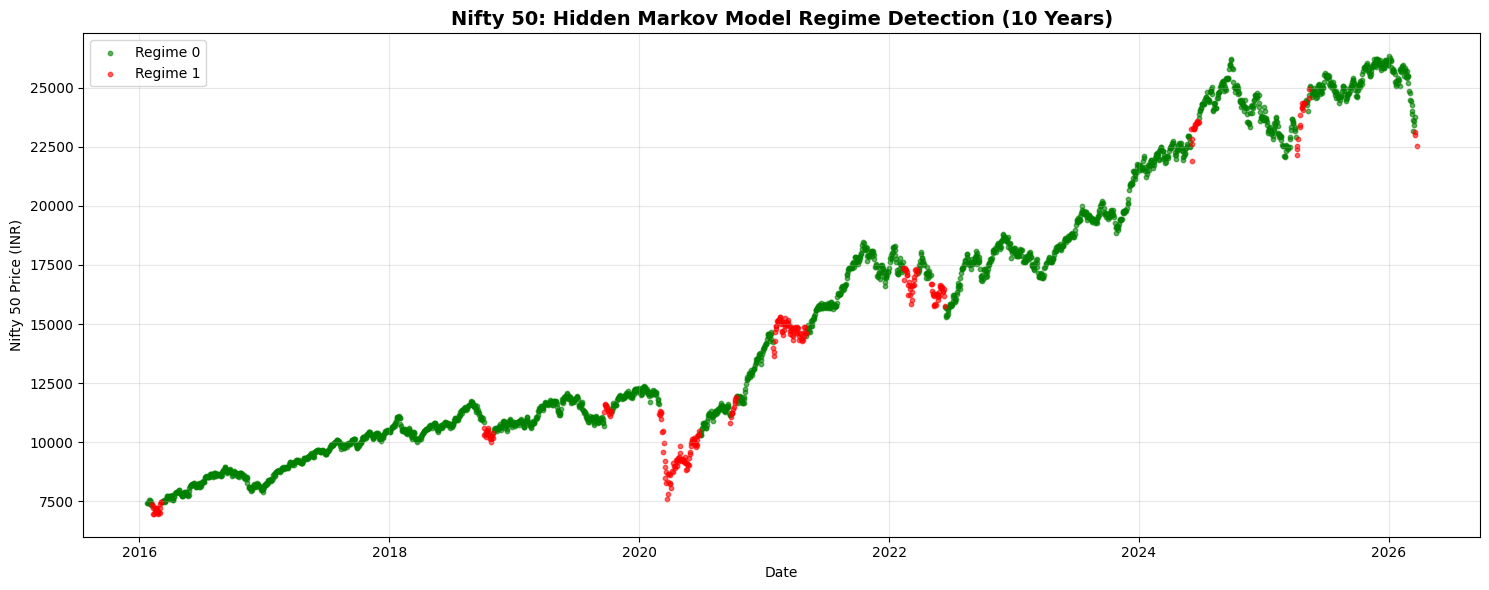

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM
import warnings

warnings.filterwarnings('ignore')

print("1. Fetching 10 Years of Nifty 50 Data...")
# Fetching the Nifty 50 Index (^NSEI)
nifty_data = yf.download('^NSEI', start='2016-01-01', end='2026-03-24')

print("2. Engineering Features (Returns & Volatility)...")
# We use Log Returns for statistical time-series stability
nifty_data['Log_Returns'] = np.log(nifty_data['Close'] / nifty_data['Close'].shift(1))
# We use a 14-day rolling standard deviation to capture volatility clusters
nifty_data['Volatility_14D'] = nifty_data['Log_Returns'].rolling(window=14).std()

# Drop the NaN values created by the rolling window and shifting
nifty_data.dropna(inplace=True)

# Create the 2D array required by hmmlearn
X_train = np.column_stack([nifty_data['Log_Returns'], nifty_data['Volatility_14D']])

print("3. Training the Hidden Markov Model (Unsupervised)...")
# We tell the math to look for 3 distinct regimes.
hmm_model = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
hmm_model.fit(X_train)

# Predict the hidden state for every single day in the last 10 years
hidden_states = hmm_model.predict(X_train)
nifty_data['Regime'] = hidden_states

print("\n" + "="*50)
print("📊 HMM REGIME INTELLIGENCE REPORT")
print("="*50)

# The algorithm assigns random numbers (0, 1, 2) to the states.
# We need to print their statistical profiles to decipher which is Bull, Bear, or Sideways.
for i in range(hmm_model.n_components):
    state_returns = nifty_data[nifty_data['Regime'] == i]['Log_Returns']
    print(f"Regime {i}:")
    print(f"  -> Average Daily Return: {state_returns.mean() * 100:.3f}%")
    print(f"  -> Daily Volatility:     {state_returns.std() * 100:.3f}%")
    print(f"  -> Days Spent in Regime: {len(state_returns)} days")
    print("-" * 30)

print("\n🔄 THE TRANSITION MATRIX (Probability of switching regimes tomorrow):")
np.set_printoptions(precision=3, suppress=True)
print(hmm_model.transmat_)
print("="*50)

# --- VISUALIZATION: Painting the Regimes ---
print("\nGenerating Market Regime Chart...")
fig, ax = plt.subplots(figsize=(15, 6))

# Define colors for our 3 regimes
colors = ['green', 'red', 'orange']

# Plot the Nifty 50 close price, coloring each segment by its hidden state
for i in range(hmm_model.n_components):
    # Create a mask for the specific regime
    mask = nifty_data['Regime'] == i
    # Scatter plot allows us to color-code individual days
    ax.scatter(nifty_data.index[mask], nifty_data['Close'][mask],
               color=colors[i], label=f'Regime {i}', s=10, alpha=0.6)

ax.set_title("Nifty 50: Hidden Markov Model Regime Detection (10 Years)", fontsize=14, fontweight='bold')
ax.set_ylabel("Nifty 50 Price (INR)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Isolate and print the exact day that triggered Regime 0
anomaly = nifty_data[nifty_data['Regime'] == 0]
print("\n🚨 THE BLACK SWAN (Regime 0):")
print(anomaly[['Close', 'Log_Returns', 'Volatility_14D']])


🚨 THE BLACK SWAN (Regime 0):
Price         Close Log_Returns Volatility_14D
Ticker        ^NSEI                           
Date                                          
2020-03-31  8597.75    0.037525       0.061454
